# Phase 1 — Exploratory Data Analysis

Goal: characterize the Phase 1 datasets (SemEval-2013 Task 7, SAF Communication Networks English, Mohler 2011) on the dimensions that matter for downstream modeling:

1. **Counts**: number of questions, answers, answers per question.
2. **Score / label distributions** with skew commentary.
3. **Answer-length distributions** (encoder-view tokens).
4. **Duplicate and missing-value ratios** (per dataset).
5. **Inter-annotator agreement** (where multiple human grades exist).
6. **Cross-dataset summary** for the writeup.

All figures are written to `reports/figures/`. The notebook auto-skips datasets whose raw files are missing, so the first run after `make download` produces all panels.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd().resolve()
while ROOT.name and not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)
print('project root:', ROOT)

project root: E:\master\فصل ثاني\NLP\exam


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from asag.config import load_data_config, ensure_dirs
from asag.data.loaders import load_all
from asag.utils.seed import set_global_seed

sns.set_theme(context='notebook', style='whitegrid')
plt.rcParams['figure.dpi'] = 110

cfg = load_data_config()
ensure_dirs(cfg)
set_global_seed(cfg.seed)
FIGDIR = cfg.paths.figures
FIGDIR.mkdir(parents=True, exist_ok=True)
print('figures ->', FIGDIR)

figures -> E:\master\فصل ثاني\NLP\exam\reports\figures


In [3]:
frames = load_all(cfg)
for name, df in frames.items():
    print(f'{name:>14s}: {len(df):>6d} rows | splits: {sorted(df.split.unique())}')

2026-05-29 16:54:37 | INFO     | asag.data.loaders:load_mohler:252 - mohler: loading canonical mohler_canonical_from_asag2024.parquet


       semeval:  16003 rows | splits: ['test_ua', 'test_ud', 'test_uq', 'train']
           saf:   2981 rows | splits: ['dev', 'test_ua', 'test_uq', 'train']
        mohler:   1260 rows | splits: ['all']
  powergrading:  13960 rows | splits: ['all']
   mindreading:  11311 rows | splits: ['all']


## 1. Per-dataset counts and split breakdown

In [4]:
rows = []
for name, df in frames.items():
    rows.append({
        'dataset': name,
        'n_rows': len(df),
        'n_questions': df['question_id'].nunique(),
        'mean_ans_per_q': round(len(df) / max(1, df['question_id'].nunique()), 2),
        'splits': ', '.join(sorted(df['split'].unique())),
        'has_score': df['score'].notna().mean().round(3),
        'has_label': (df['label'].astype(str).str.len() > 0).mean().round(3),
    })
summary = pd.DataFrame(rows)
summary

,dataset,n_rows,n_questions,mean_ans_per_q,splits,has_score,has_label
0,semeval,16003,252,63.50,"test_ua, test_ud, test_uq, train",0.0,1.0
1,saf,2981,31,96.16,"dev, test_ua, test_uq, train",1.0,1.0
2,mohler,1260,21,60.00,all,1.0,0.0
3,powergrading,13960,20,698.00,all,1.0,1.0
4,mindreading,11311,11,1028.27,all,1.0,1.0


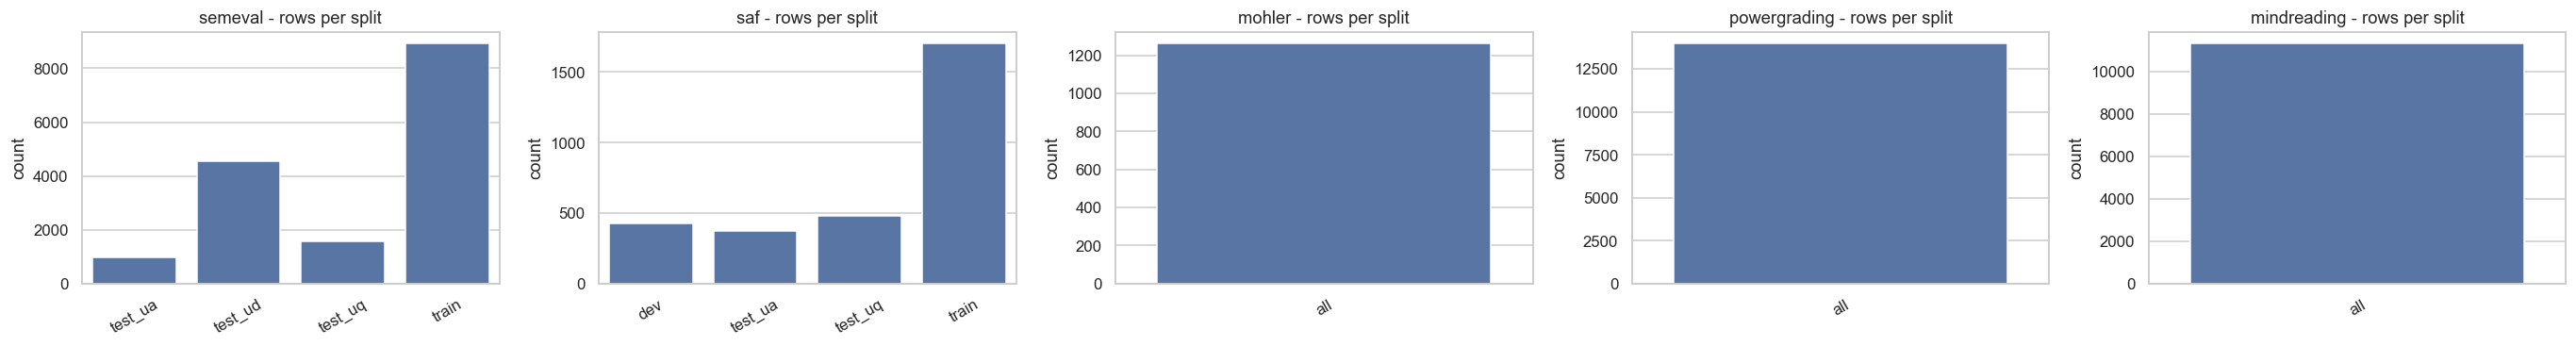

In [5]:
fig, axes = plt.subplots(1, len(frames), figsize=(5*len(frames), 3.5), squeeze=False)
for ax, (name, df) in zip(axes[0], frames.items()):
    counts = df['split'].value_counts().sort_index()
    sns.barplot(x=counts.index.tolist(), y=counts.values, ax=ax)
    ax.set_title(f'{name} - rows per split')
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
fig.savefig(FIGDIR / 'splits_by_dataset.png', bbox_inches='tight')
plt.show()

## 2. Score and label distributions

Mohler is expected to skew toward 5; SAF is on a 0-3.5 float scale; SemEval is categorical (label only).

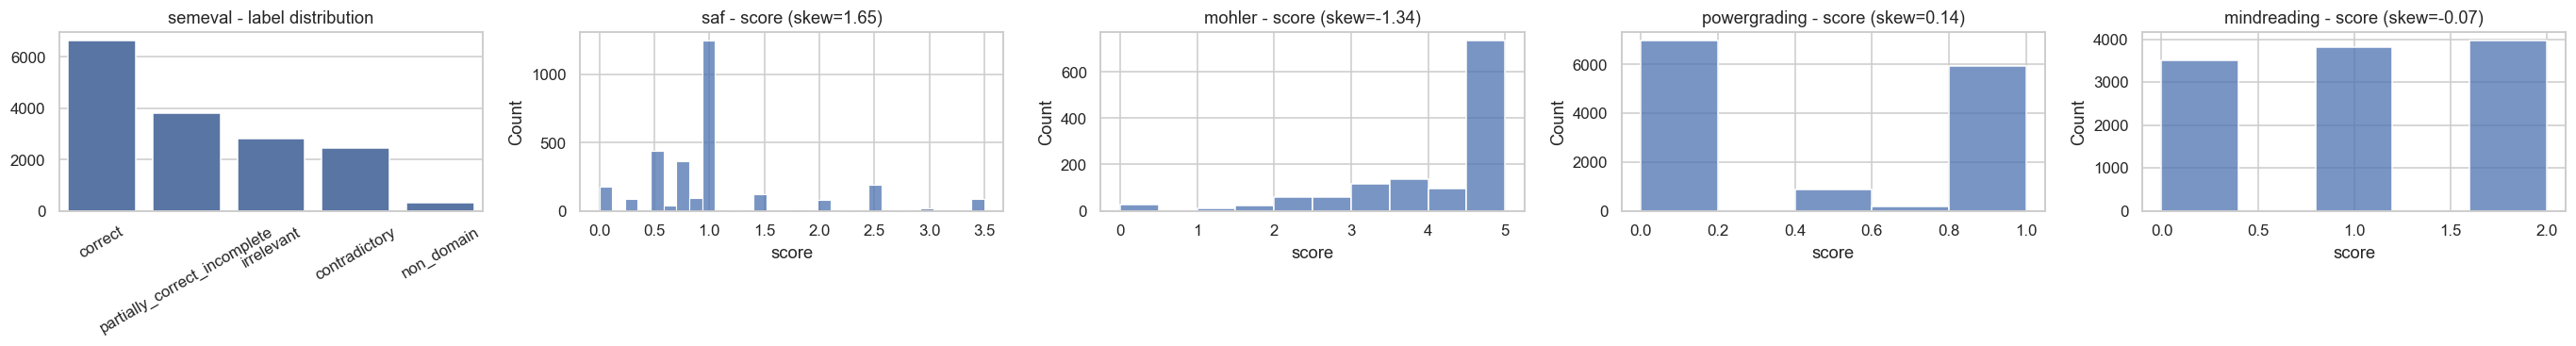

In [6]:
fig, axes = plt.subplots(1, len(frames), figsize=(5*len(frames), 3.5), squeeze=False)
for ax, (name, df) in zip(axes[0], frames.items()):
    s = df['score'].dropna()
    if len(s) == 0:
        lab_counts = df['label'].value_counts()
        sns.barplot(x=lab_counts.index.tolist(), y=lab_counts.values, ax=ax)
        ax.set_title(f'{name} - label distribution')
        ax.tick_params(axis='x', rotation=30)
    else:
        sns.histplot(s, bins=min(30, max(5, int(s.nunique()))), ax=ax, kde=False)
        skew = s.skew()
        ax.set_title(f'{name} - score (skew={skew:.2f})')
        ax.set_xlabel('score')
fig.tight_layout()
fig.savefig(FIGDIR / 'score_or_label_dist.png', bbox_inches='tight')
plt.show()

## 3. Answer-length distribution (encoder view tokens)

Whitespace token counts as a proxy. Phase 2 will use the actual SBERT/DeBERTa tokenizer for length-budget decisions.

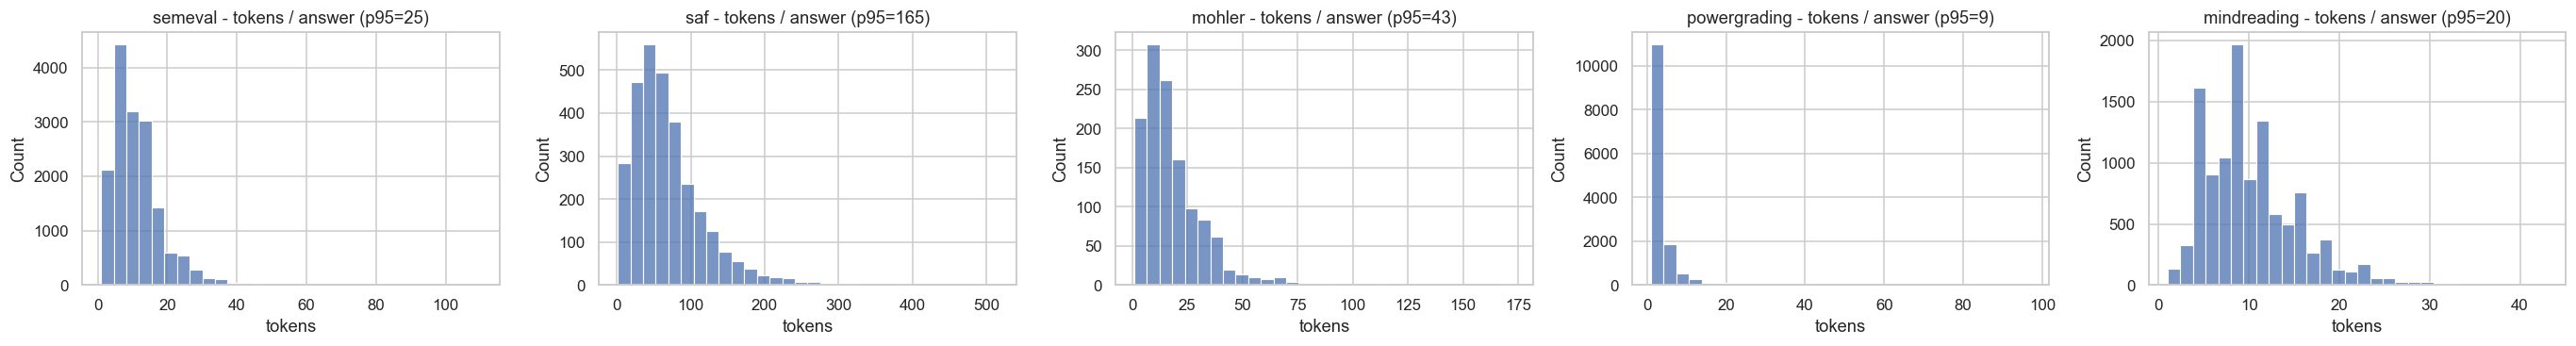

In [7]:
fig, axes = plt.subplots(1, len(frames), figsize=(5*len(frames), 3.5), squeeze=False)
for ax, (name, df) in zip(axes[0], frames.items()):
    lens = df['student_answer'].astype(str).str.split().map(len)
    sns.histplot(lens, bins=30, ax=ax, kde=False)
    ax.set_title(f'{name} - tokens / answer (p95={int(np.percentile(lens, 95))})')
    ax.set_xlabel('tokens')
fig.tight_layout()
fig.savefig(FIGDIR / 'answer_length.png', bbox_inches='tight')
plt.show()

## 4. Duplicates and missing values

In [8]:
from asag.data.validate import check_duplicates, check_missing

rows = []
for name, df in frames.items():
    miss = check_missing(df)
    dup = check_duplicates(df, near_threshold=cfg.validation.near_duplicate_jaccard_threshold)
    rows.append({
        'dataset': name,
        'n_rows': len(df),
        'q_empty': miss['question_empty'],
        'ref_empty': miss['reference_answer_empty'],
        'sa_empty': miss['student_answer_empty'],
        'score_nan': miss['score_nan'],
        'exact_dups': dup['exact_duplicate_rows'],
        'near_dups': dup['near_duplicate_pairs'],
    })
dup_miss = pd.DataFrame(rows)
dup_miss

,dataset,n_rows,q_empty,ref_empty,sa_empty,score_nan,exact_dups,near_dups
0,semeval,16003,0,0,0,16003,527,0
1,saf,2981,0,0,0,0,57,2
2,mohler,1260,0,0,0,0,644,0
3,powergrading,13960,0,0,0,0,9019,0
4,mindreading,11311,0,11311,0,0,768,0


## 5. Inter-annotator agreement (where available)

SAF stores verification_feedback (a derived label) alongside score; in this notebook we focus on what's available in our unified schema. Mohler's avg score already combines the two graders, so per-grader IAA cannot be reconstructed from our loader. ASAP-SAS would expose Score1 vs Score2 — added in Phase 2 once enabled.

,count,mean,std
label,,,
Correct,1802,1.272,0.717
Incorrect,173,0.000,0.000
Partially correct,1006,0.789,0.506


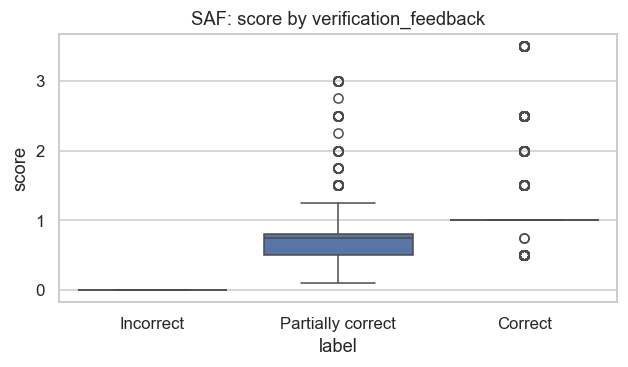

In [9]:
# Sanity: SAF verification_feedback vs continuous score (should monotonically relate)
if 'saf' in frames:
    saf = frames['saf']
    g = saf.groupby('label')['score'].agg(['count', 'mean', 'std']).round(3)
    display(g)
    fig, ax = plt.subplots(figsize=(6, 3.5))
    sns.boxplot(data=saf, x='label', y='score', ax=ax,
                order=[l for l in ['Incorrect', 'Partially correct', 'Correct'] if l in saf['label'].unique()])
    ax.set_title('SAF: score by verification_feedback')
    fig.tight_layout()
    fig.savefig(FIGDIR / 'saf_score_by_label.png', bbox_inches='tight')
    plt.show()

## 6. Cross-dataset summary

In [10]:
rows = []
for name, df in frames.items():
    s = df['score'].dropna()
    rows.append({
        'dataset': name,
        'domain': df['domain'].mode().iat[0] if len(df) else '',
        'N_q': df['question_id'].nunique(),
        'N_a': len(df),
        'mean_len_tokens': int(df['student_answer'].astype(str).str.split().map(len).mean()) if len(df) else 0,
        'score_min': round(s.min(), 2) if len(s) else None,
        'score_max': round(s.max(), 2) if len(s) else None,
        'splits': ', '.join(sorted(df['split'].unique())),
    })
cross = pd.DataFrame(rows)
cross.to_csv(cfg.paths.reports / 'dataset_summary.csv', index=False)
cross

,dataset,domain,N_q,N_a,mean_len_tokens,score_min,score_max,splits
0,semeval,science,252,16003,11,NaN,NaN,"test_ua, test_ud, test_uq, train"
1,saf,comm_networks,31,2981,69,0.0,3.5,"dev, test_ua, test_uq, train"
2,mohler,cs_data_structures,21,1260,18,0.0,5.0,all
3,powergrading,civics,20,13960,3,0.0,1.0,all
4,mindreading,mindreading_behavioral,11,11311,10,0.0,2.0,all


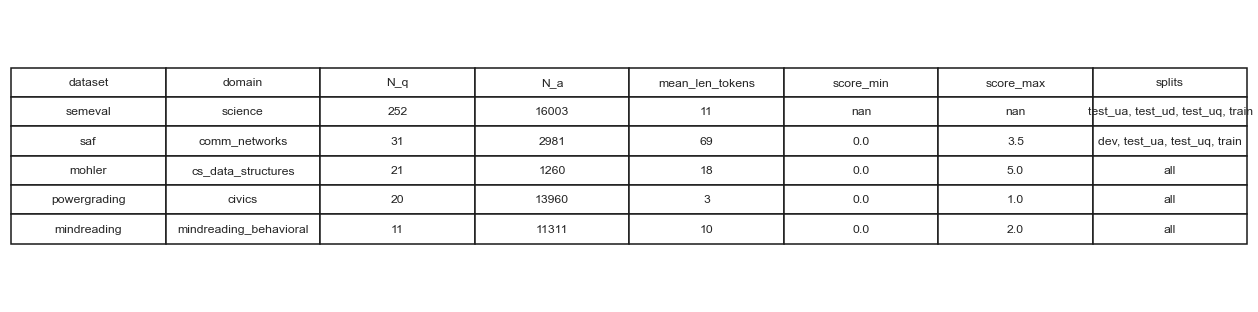

wrote E:\master\فصل ثاني\NLP\exam\reports\figures\dataset_summary.png


In [11]:
# Save a single combined summary image for the report writeup
fig, ax = plt.subplots(figsize=(min(2 + 1.2*len(cross.columns), 14), 0.5 + 0.5*len(cross)))
ax.axis('off')
tab = ax.table(cellText=cross.astype(str).values, colLabels=cross.columns.tolist(), loc='center', cellLoc='center')
tab.auto_set_font_size(False)
tab.set_fontsize(8)
tab.scale(1, 1.4)
fig.tight_layout()
fig.savefig(FIGDIR / 'dataset_summary.png', bbox_inches='tight')
plt.show()
print('wrote', FIGDIR / 'dataset_summary.png')